# Rossmann Sales Forecasting — Encoder-Decoder RNN

Rewrite of the original `rossmann_test` notebook. Structure:

1. **Load & merge** the raw files with the store metadata
2. **Feature engineering** (kept from the original script, one small bug fixed)
3. **Chronological train / validation / holdout split**, implemented as a *lazy*, per-store sliding-window `Dataset` — no giant Python list of window slices is ever materialized, the tensors are sliced on demand directly out of one tensor per store
4. **Encoder-decoder RNN** that predicts the sales of a day from its own past window (past features **and** past sales) *and* from the known future features of the days being forecast
5. **Holdout evaluation**: pick a store, forecast `N_STEPS_OUT` days ahead from its past window, and plot actual vs. predicted


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from types import SimpleNamespace


In [2]:
DATA_DIR = "./dataset"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# ----------------------------- RNN hyper-parameters -----------------------------
N_STEPS_IN = 100    # length (in days) of the input window fed to the encoder
N_STEPS_OUT = 48    # length (in days) of the forecast horizon (~ len(test.csv) per store)
WINDOW_LEN = N_STEPS_IN + N_STEPS_OUT

BATCH_SIZE = 64
N_EPOCHS = 30
LEARNING_RATE = 1e-3

HIDDEN_SIZE = 32

# Stride between two consecutive windows of the SAME store. Windows are sliced
# lazily (see RossmannWindowDataset below), so the stride only controls how many
# overlapping training examples exist -- it has no impact on memory usage.
TRAIN_STRIDE = 7            # one window per week of overlap during training
EVAL_STRIDE = N_STEPS_OUT   # non-overlapping windows for validation / holdout

# The two dates that define the chronological split. Every window (its input
# part AND its target part) must fall entirely inside the interval of the split
# it is assigned to -- this is what prevents leakage between train/val/holdout,
# see RossmannWindowDataset for how this constraint is enforced.
VAL_DAYS = 200       # length (in days) of the validation interval, right before the holdout
HOLDOUT_DAYS = 200   # length (in days) of the holdout interval, at the very end of the series

DATA_CUT = None  # optionally cut the number of raw rows for a fast local smoke-test

SELECTED_STORE = 2  # store used for the final qualitative forecast plot (step 5)


In [3]:
def assess_device():
    '''Return the best available device: MPS, CUDA, then CPU.'''
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


device = assess_device()
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


## 1. Load files and merge with store metadata

In [4]:
train_raw = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv"),
    parse_dates=["Date"], dtype={"StateHoliday": str}, low_memory=False,
)[:DATA_CUT]
test_raw = pd.read_csv(
    os.path.join(DATA_DIR, "test.csv"),
    parse_dates=["Date"], dtype={"StateHoliday": str}, low_memory=False,
)
store = pd.read_csv(os.path.join(DATA_DIR, "store.csv"))

# bring the store metadata (StoreType, Assortment, competition/promo info, ...)
# onto every row of train/test
train_df = train_raw.merge(store, how="left", on="Store")
test_df = test_raw.merge(store, how="left", on="Store")

# rows must be strictly chronological *within* each store for the sliding
# windows built in section 3 to make sense
train_df = train_df.sort_values(["Store", "Date"]).reset_index(drop=True)
test_df = test_df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(train_df.dtypes)
print("-" * 70)
print(test_df.dtypes)


Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object
----------------------------------------------------------------------
Id                                    int64
Store                                 int64
DayOfWeek                          

In [5]:
# correct data issues

print(f"Missing values in Open (test): {test_df['Open'].isnull().sum()}")
test_df["Open"] = test_df["Open"].fillna(1).astype(int)

competition_distance_mean = store["CompetitionDistance"].mean()


Missing values in Open (test): 11


## 2. Feature engineering

Kept from the original script (it was already appropriate); the only change is a small fix so that `drop_date=True` no longer tries to drop the `DayOfWeek` column twice.

In [6]:
def engineer_features(df, drop_date=False, drop_store=False):

    df = df.copy()

    _year = df["Date"].dt.year
    _month = df["Date"].dt.month
    _day_of_year = df["Date"].dt.dayofyear
    _week_of_year = df["Date"].dt.isocalendar().week.astype(int)
    _day_of_week = df["Date"].dt.dayofweek + 1  # Monday=1, Sunday=7

    # Day of year is a cyclical feature, encoded via sine/cosine
    df["DayOfYear_sin"] = np.sin(2 * np.pi * _day_of_year / 365)
    df["DayOfYear_cos"] = np.cos(2 * np.pi * _day_of_year / 365)
    if drop_date:
        df = df.drop(columns=["Date"])

    # Day of week is also cyclical
    df["DayOfWeek_sin"] = np.sin(2 * np.pi * _day_of_week / 7)
    df["DayOfWeek_cos"] = np.cos(2 * np.pi * _day_of_week / 7)
    df = df.drop(columns=["DayOfWeek"])

    # Not needed for forecasting future days (unknown at prediction time)
    if "Customers" in df.columns:
        df = df.drop(columns=["Customers"])

    # Merge the three types of holidays into a single binary feature
    df["StateHoliday"] = (df["StateHoliday"] != "0").astype(int)

    # Map "Assortment" to numerical values: "a" -> 0, "b" -> 1, "c" -> 2
    df["Assortment"] = df["Assortment"].map({"a": 0, "b": 1, "c": 2})

    # Fill missing "CompetitionDistance" with the (global) mean
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(competition_distance_mean)

    # Months since the competition opened (0 if unknown / not yet opened)
    competition_open_months = (
        12 * (_year - df["CompetitionOpenSinceYear"])
        + (_month - df["CompetitionOpenSinceMonth"])
    )
    df["CompetitionOpenMonths"] = competition_open_months.fillna(0).clip(lower=0)
    df = df.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"])

    # Weeks since the second promotion (Promo2) started
    promo2_open_weeks = (
        52 * (_year - df["Promo2SinceYear"])
        + (_week_of_year - df["Promo2SinceWeek"])
    )
    df["Promo2OpenWeeks"] = promo2_open_weeks.fillna(0).clip(lower=0)
    df = df.drop(columns=["Promo2SinceWeek", "Promo2SinceYear"])

    # One-hot encode "StoreType"
    storetype_dummies = pd.get_dummies(df["StoreType"], prefix="StoreType").astype(int)
    df = pd.concat([df.drop(columns=["StoreType"]), storetype_dummies], axis=1)

    # Binary flag: is the current month one of the store's Promo2 months?
    month_abbr = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                  7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
    _month_str = _month.map(month_abbr)
    _promo_month_list = df["PromoInterval"].fillna("").str.split(",")
    df["IsPromoMonth"] = _month_str.isin(_promo_month_list).astype(int)
    df = df.drop(columns=["PromoInterval"])

    # Log-transform the target (if present -- absent in test.csv)
    if "Sales" in df.columns:
        df["SalesLog"] = np.log1p(df["Sales"])

    if drop_store and "Store" in df.columns:
        df = df.drop(columns=["Store"])

    return df


In [7]:
train_df = engineer_features(train_df, drop_store=False)
test_df = engineer_features(test_df, drop_store=False)

feature_cols = [
    c for c in train_df.columns
    if c not in ("Store", "Date", "Sales", "SalesLog", "Id")
]
target_col = "SalesLog"

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print("-" * 70)
print(train_df.dtypes)


Feature columns (18): ['Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Assortment', 'CompetitionDistance', 'Promo2', 'DayOfYear_sin', 'DayOfYear_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'CompetitionOpenMonths', 'Promo2OpenWeeks', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'IsPromoMonth']
----------------------------------------------------------------------
Store                             int64
Date                     datetime64[ns]
Sales                             int64
Open                              int64
Promo                             int64
StateHoliday                      int64
SchoolHoliday                     int64
Assortment                        int64
CompetitionDistance             float64
Promo2                            int64
DayOfYear_sin                   float64
DayOfYear_cos                   float64
DayOfWeek_sin                   float64
DayOfWeek_cos                   float64
CompetitionOpenMonths           float64
Promo2OpenWeeks      

In [8]:
# Drop the (rare) anomalous rows where the store was open but sold nothing --
# they distort the log-sales scaling. Only applied to the training data.
train_df = train_df.drop(train_df[(train_df["Open"] == 1) & (train_df["Sales"] < 1)].index)


## 3. Chronological split, scaling, and lazy window datasets

**Splitting strategy.** Two cutoff dates `cutoff1 < cutoff2` carve the training file into three
non-overlapping *time* intervals:

* train &nbsp;&rarr;&nbsp; `(-inf, cutoff1]`
* validation &nbsp;&rarr;&nbsp; `(cutoff1, cutoff2]`
* holdout &nbsp;&rarr;&nbsp; `(cutoff2, +inf)`

A window (its `N_STEPS_IN` past days **and** its `N_STEPS_OUT` future days) is assigned to a split
only if *every single day it touches* lies inside that split's interval. Windows that straddle a
cutoff are simply dropped (from both neighbouring splits), so there is no leakage. Because the
split is a hard function of the date, it stays perfectly chronological (train < val < holdout) and
splitting is deterministic, not random.

**Avoiding leakage in preprocessing too.** The min/max used to rescale every feature (and the
target) are fit *only* on rows dated on or before `cutoff1` (the training interval), then applied
to the whole dataset -- so no statistic derived from validation/holdout dates ever leaks into the
scaling of the training set.

**Windowing without giant intermediate arrays.** Instead of building a Python list of one
DataFrame slice per window and only then converting everything to a big numpy array (what the
original `sliding_windows_date` did), we build **one tensor per store** just once (mirroring how
`Recurrent_Torch.ipynb`'s `make_loaders` turns the raw data directly into tensors, with no
per-window intermediate). Each split's `Dataset` only stores a lightweight list of
`(store_id, window_start)` index pairs and slices directly into that shared per-store tensor in
`__getitem__`. Because indices are generated store-by-store, a window can never mix rows from two
different stores.

In [9]:
date_min = train_df["Date"].min()
date_max = train_df["Date"].max()

cutoff2 = date_max - pd.Timedelta(days=HOLDOUT_DAYS)
cutoff1 = cutoff2 - pd.Timedelta(days=VAL_DAYS)

assert cutoff1 > date_min, "Not enough history before the validation interval."
assert (cutoff1 - date_min).days >= WINDOW_LEN, "Training interval shorter than a single window."
assert VAL_DAYS >= WINDOW_LEN, "Validation interval shorter than a single window: it would contain zero windows."
assert HOLDOUT_DAYS >= WINDOW_LEN, "Holdout interval shorter than a single window: it would contain zero windows."

print(f"train:      {date_min.date()}  ->  {cutoff1.date()}")
print(f"validation: {cutoff1.date()}  ->  {cutoff2.date()}")
print(f"holdout:    {cutoff2.date()}  ->  {date_max.date()}")


train:      2013-01-01  ->  2014-06-26
validation: 2014-06-26  ->  2015-01-12
holdout:    2015-01-12  ->  2015-07-31


In [10]:
def fit_scaler(df, cols):
    '''Fit min/max scaling statistics on `df` (should be the TRAIN interval only).'''
    mins = df[cols].min()
    ranges = (df[cols].max() - mins).replace(0, 1.0)  # avoid division by zero
    return {"min": mins, "range": ranges}


def apply_scaler(df, cols, scaler):
    df = df.copy()
    df[cols] = (df[cols] - scaler["min"][cols]) / scaler["range"][cols]
    return df


def invert_scale(values, col, scaler):
    '''Undo apply_scaler for a single column (accepts a numpy array or scalar).'''
    return values * scaler["range"][col] + scaler["min"][col]


# fit only on the rows that belong to the training interval -> no leakage
train_interval_mask = train_df["Date"] <= cutoff1
scaled_cols = feature_cols + [target_col]
scaler = fit_scaler(train_df.loc[train_interval_mask], scaled_cols)

train_df_scaled = apply_scaler(train_df, scaled_cols, scaler)
test_df_scaled = apply_scaler(test_df, feature_cols, scaler)  # kept ready for a future submission step

train_df_scaled[scaled_cols].head()


,Open,Promo,StateHoliday,SchoolHoliday,Assortment,CompetitionDistance,Promo2,DayOfYear_sin,DayOfYear_cos,DayOfWeek_sin,DayOfWeek_cos,CompetitionOpenMonths,Promo2OpenWeeks,StoreType_a,StoreType_b,StoreType_c,StoreType_d,IsPromoMonth,SalesLog
0,0.0,0.0,1.0,1.0,0.0,0.016482,0.0,0.508607,0.999926,1.000000,3.568959e-01,0.037873,0.0,0.0,0.0,1.0,0.0,0.0,0.000000
1,1.0,0.0,0.0,1.0,0.0,0.016482,0.0,0.517211,0.999704,0.722521,5.840301e-17,0.037873,0.0,0.0,0.0,1.0,0.0,0.0,0.817167
2,1.0,0.0,0.0,1.0,0.0,0.016482,0.0,0.525810,0.999333,0.277479,0.000000e+00,0.037873,0.0,0.0,0.0,1.0,0.0,0.0,0.793911
3,1.0,0.0,0.0,1.0,0.0,0.016482,0.0,0.534402,0.998815,0.000000,3.568959e-01,0.037873,0.0,0.0,0.0,1.0,0.0,0.0,0.797332
4,1.0,0.0,0.0,1.0,0.0,0.016482,0.0,0.542983,0.998149,0.099031,8.019377e-01,0.037873,0.0,0.0,0.0,1.0,0.0,0.0,0.807559


In [ ]:
class RossmannWindowDataset(Dataset):
    '''Lazily-indexed sliding-window dataset for a multi-store time series.

    Rather than materialising every window in memory, this dataset:
      1. relies on a per-store tensor bank built ONCE (`build_store_tensor_bank`),
         with shape (T_store, n_features + 1) -- the +1 is the target column,
         appended last, so that it doubles as "past sales" when slicing the
         input window and as the label when slicing the target window;
      2. stores only a lightweight list of (store_id, window_start) integer
         pairs whose window falls entirely inside [lo, hi];
      3. slices tensors on-the-fly in __getitem__ (a cheap view, no copy).

    Because indices are built store-by-store, a window never mixes rows from
    two different stores.
    '''

    def __init__(self, bank, n_steps_in, n_steps_out, lo=None, hi=None, stride=1):
        self.bank = bank # Dictionary of per-store tesors dataframes. See "build_store_tensor_bank".
        self.n_in = n_steps_in
        self.n_out = n_steps_out
        window_len = n_steps_in + n_steps_out

        # Time bounds for this specific split; NOT the bound between train, validation and holdout.
        lo64 = np.datetime64(lo) if lo is not None else None
        hi64 = np.datetime64(hi) if hi is not None else None

        self.index = [] # it will have shape (n_windows, 2) and contain (store_id, window_start_index) pairs
        for store_id, (values, dates) in bank.items():  # values not necessary as only dates are used to define the windows
            n = len(dates)
            for i in range(0, n - window_len + 1, stride):
                win_start, win_end = dates[i], dates[i + window_len - 1]
                if lo64 is not None and win_start <= lo64:
                    continue  # window starts before (or on) the split's lower bound => skip to next iteration of the for loop
                if hi64 is not None and win_end > hi64:
                    continue  # window ends after the split's upper bound => skip to next iteration of the for loop
                self.index.append((store_id, i))

    def __len__(self):
        return len(self.index) # total number of windows inside the specified [lo, hi] interval

    def __getitem__(self, idx):
        store_id, i = self.index[idx]       # "idx" is a generic index, not corresponding to the store's own index
        values, _ = self.bank[store_id]     # tensor dataframe of said store

        x = values[i: i + self.n_in]                                        # creation of past features + sales
        future_block = values[i + self.n_in: i + self.n_in + self.n_out]    # creation of future features + sales 
        future_features = future_block[:, :-1]                              # removing the last column (sales) from the future block
        y = future_block[:, -1]                                             # last column of the future block (sales to predict)

        return x, future_features, y


def build_store_tensor_bank(df, feature_cols, target_col):
    '''Build one contiguous (features + target) tensor per store, 
        so that the values can be accessed just by index.'''
    bank = {}
    cols = feature_cols + [target_col]
    for store_id, store_df in df.groupby("Store", sort=False):
        store_df = store_df.sort_values("Date")
        values = torch.from_numpy(store_df[cols].to_numpy(dtype=np.float32))
        dates = store_df["Date"].to_numpy()
        bank[store_id] = (values, dates) 
    return bank


In [12]:
bank = build_store_tensor_bank(train_df_scaled, feature_cols, target_col)

train_ds = RossmannWindowDataset(bank, N_STEPS_IN, N_STEPS_OUT, lo=None, hi=cutoff1, stride=TRAIN_STRIDE)
val_ds = RossmannWindowDataset(bank, N_STEPS_IN, N_STEPS_OUT, lo=cutoff1, hi=cutoff2, stride=EVAL_STRIDE)
holdout_ds = RossmannWindowDataset(bank, N_STEPS_IN, N_STEPS_OUT, lo=cutoff2, hi=None, stride=EVAL_STRIDE)

print(f"stores in bank: {len(bank)}")
print(f"train windows:      {len(train_ds):>7,d}")
print(f"validation windows: {len(val_ds):>7,d}")
print(f"holdout windows:    {len(holdout_ds):>7,d}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
holdout_loader = DataLoader(holdout_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, fb, yb = next(iter(train_loader))
print(f"batch shapes -> x: {tuple(xb.shape)}  future_features: {tuple(fb.shape)}  y: {tuple(yb.shape)}")


stores in bank: 1115
train windows:       63,555
validation windows:     935
holdout windows:      1,115
batch shapes -> x: (64, 100, 19)  future_features: (64, 48, 18)  y: (64, 48)


## 4. Encoder-decoder RNN model

* The **encoder** consumes the `N_STEPS_IN`-day past window: every engineered feature of the store/day, *plus* the store's own past sales.
* Its final hidden state is broadcast to all `N_STEPS_OUT` decoding steps and concatenated, at each step, with that day's *known* future features (promo calendar, holidays, day-of-week, ...).
* The **decoder** turns that into a sales forecast for each of the `N_STEPS_OUT` future days -- i.e. every prediction is conditioned on the past (features + sales) *and* on the specific characteristics of the day being predicted.

In [ ]:
def init_input_identity(recurrent_layer, gain=1.0):
    with torch.no_grad():
        for name, param in recurrent_layer.named_parameters():
            if "weight_ih" in name:
                param.zero_()
                rows, cols = param.shape
                diag = min(rows, cols)
                param[:diag, :diag] = gain * torch.eye(diag, device=param.device)


class DeepEncoderDecoderRNN(nn.Module):
    '''Encoder-decoder RNN that conditions every forecast step on future features.'''

    def __init__(self, input_size, hidden_size=32, output_size=1, out_steps=1, future_feature_size=None):
        super().__init__()
        self.out_steps = out_steps
        self.future_feature_size = input_size - output_size if future_feature_size is None else future_feature_size
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.GRU(hidden_size + self.future_feature_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        init_input_identity(self.encoder, gain=1.0)
        init_input_identity(self.decoder, gain=1.0)

    def forward(self, x, future_features=None):
        encoder_out, _ = self.encoder(x)
        context = encoder_out[:, -1:, :].repeat(1, self.out_steps, 1)

        if future_features is None:
            future_features = torch.zeros(
                x.size(0), self.out_steps, self.future_feature_size,
                dtype=x.dtype, device=x.device,
            )
        if future_features.shape[1:] != (self.out_steps, self.future_feature_size):
            raise ValueError(
                f"future_features must have shape (batch, {self.out_steps}, "
                f"{self.future_feature_size}), got {tuple(future_features.shape)}"
            )

        decoder_input = torch.cat([context, future_features], dim=-1)
        decoder_out, _ = self.decoder(decoder_input)
        forecast = self.fc(decoder_out)
        return forecast.squeeze(-1)


def summarize_model(model, input_shape, future_shape=None):
    print(model)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")
    x_sample = torch.zeros(input_shape, dtype=torch.float32, device=device)
    f_sample = torch.zeros(future_shape, dtype=torch.float32, device=device) if future_shape else None
    model.eval()
    with torch.inference_mode():
        output = model(x_sample, f_sample)
    print(f"Input shape: {tuple(x_sample.shape)}")
    if f_sample is not None:
        print(f"Future features shape: {tuple(f_sample.shape)}")
    print(f"Output shape: {tuple(output.shape)}")


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    '''One pass over `loader`. Trains if `optimizer` is given, evaluates otherwise.'''
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total = 0.0, 0
    grad_context = torch.enable_grad() if is_train else torch.inference_mode()
    with grad_context:
        for x, future_features, y in loader:
            x = x.to(device)
            future_features = future_features.to(device)
            y = y.to(device)

            if is_train:
                optimizer.zero_grad()

            pred = model(x, future_features)
            loss = criterion(pred, y)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)

    return total_loss / total


def fit(model, train_loader, val_loader, epochs=N_EPOCHS, lr=LEARNING_RATE):
    '''Actual training loop, performs both training and validation, returning the losses history.'''
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        train_loss = run_epoch(model, train_loader, criterion, optimizer)
        val_loss = run_epoch(model, val_loader, criterion, optimizer=None)
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"epoch {epoch + 1:3d}/{epochs}  loss={train_loss:.5f}  val_loss={val_loss:.5f}")

    return SimpleNamespace(history=history)


In [15]:
n_future_features = len(feature_cols)   # known future features (no sales)
n_input_features = n_future_features + 1  # + the store's own past sales

model = DeepEncoderDecoderRNN(
    input_size=n_input_features,
    hidden_size=HIDDEN_SIZE,
    output_size=1,
    out_steps=N_STEPS_OUT,
    future_feature_size=n_future_features,
).to(device)

summarize_model(
    model,
    input_shape=(1, N_STEPS_IN, n_input_features),
    future_shape=(1, N_STEPS_OUT, n_future_features),
)

hist = fit(model, train_loader, val_loader, epochs=N_EPOCHS, lr=LEARNING_RATE)


DeepEncoderDecoderRNN(
  (encoder): LSTM(19, 32, batch_first=True)
  (decoder): GRU(50, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Trainable parameters: 14,881
Input shape: (1, 100, 19)
Future features shape: (1, 48, 18)
Output shape: (1, 48)
epoch   1/30  loss=0.01707  val_loss=0.00177
epoch   2/30  loss=0.00099  val_loss=0.00135
epoch   3/30  loss=0.00054  val_loss=0.00054
epoch   4/30  loss=0.00040  val_loss=0.00083
epoch   5/30  loss=0.00036  val_loss=0.00067
epoch   6/30  loss=0.00034  val_loss=0.00057
epoch   7/30  loss=0.00032  val_loss=0.00066
epoch   8/30  loss=0.00030  val_loss=0.00048
epoch   9/30  loss=0.00027  val_loss=0.00049
epoch  10/30  loss=0.00027  val_loss=0.00063
epoch  11/30  loss=0.00025  val_loss=0.00043
epoch  12/30  loss=0.00024  val_loss=0.00069
epoch  13/30  loss=0.00023  val_loss=0.00043
epoch  14/30  loss=0.00023  val_loss=0.00042
epoch  15/30  loss=0.00022  val_loss=0.00040
epoch  16/30  loss=0.00022  val_loss=0.0006

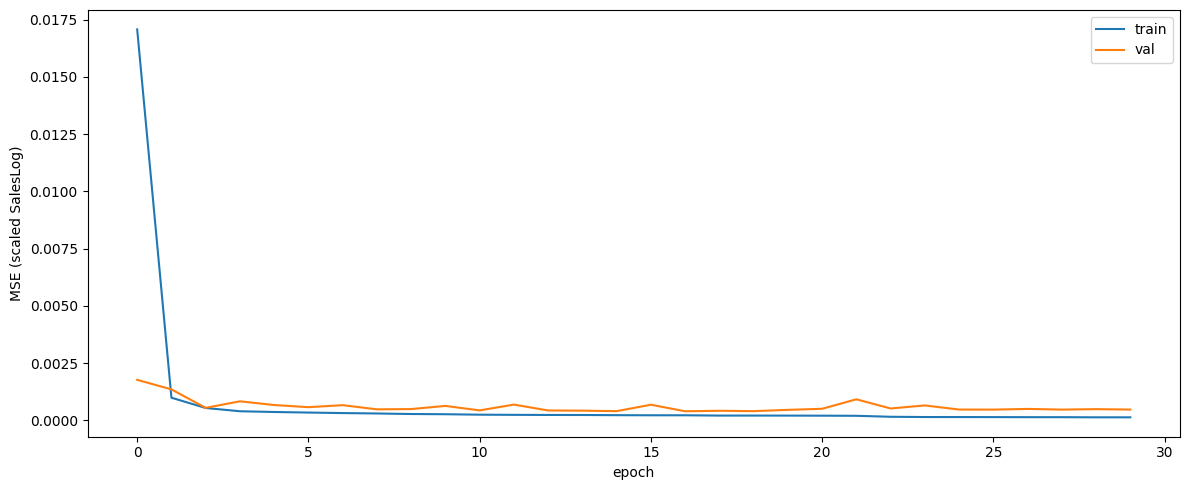

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE (scaled SalesLog)")
plt.legend()
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"))
plt.show()


## 5. Holdout evaluation

Holdout MSE (scaled SalesLog space): 0.00029
Store 2 - 48-day holdout forecast - MAE: 602.6  RMSE: 879.3


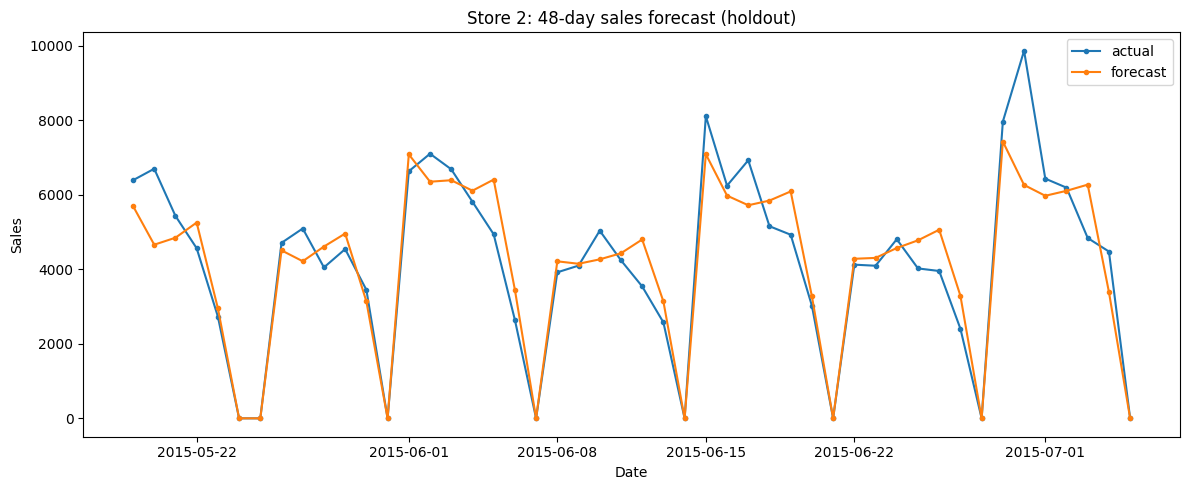

In [17]:
# Overall accuracy across every window of the untouched holdout interval
holdout_mse = run_epoch(model, holdout_loader, nn.MSELoss(), optimizer=None)
print(f"Holdout MSE (scaled SalesLog space): {holdout_mse:.5f}")


def pick_window(dataset, store_id=None):
    '''Return the first (store_id, window_start) in `dataset` for the given store
    (or simply the first window in the dataset if store_id is None / not found).'''
    if store_id is not None:
        for sid, i in dataset.index:
            if sid == store_id:
                return sid, i
        print(f"Store {store_id} has no window in this split, falling back to another store.")
    return dataset.index[0]


example_store, example_i = pick_window(holdout_ds, store_id=SELECTED_STORE)
values, dates = holdout_ds.bank[example_store]

x = values[example_i: example_i + N_STEPS_IN].unsqueeze(0).to(device)
future_block = values[example_i + N_STEPS_IN: example_i + N_STEPS_IN + N_STEPS_OUT]
future_features = future_block[:, :-1].unsqueeze(0).to(device)
y_true_scaled = future_block[:, -1].numpy()
forecast_dates = dates[example_i + N_STEPS_IN: example_i + N_STEPS_IN + N_STEPS_OUT]

model.eval()
with torch.inference_mode():
    y_pred_scaled = model(x, future_features).cpu().numpy().ravel()

# undo scaling + log1p to report the forecast in actual Sales units
y_true_log = invert_scale(y_true_scaled, target_col, scaler)
y_pred_log = invert_scale(y_pred_scaled, target_col, scaler)
y_true_sales = np.expm1(y_true_log)
y_pred_sales = np.expm1(y_pred_log)

mae = np.mean(np.abs(y_pred_sales - y_true_sales))
rmse = np.sqrt(np.mean((y_pred_sales - y_true_sales) ** 2))
print(f"Store {example_store} - {N_STEPS_OUT}-day holdout forecast - MAE: {mae:.1f}  RMSE: {rmse:.1f}")

plt.figure(figsize=(12, 5))
plt.plot(forecast_dates, y_true_sales, label="actual", marker="o", markersize=3)
plt.plot(forecast_dates, y_pred_sales, label="forecast", marker="o", markersize=3)
plt.title(f"Store {example_store}: {N_STEPS_OUT}-day sales forecast (holdout)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"holdout_forecast_store_{example_store}.png"))
plt.show()
